<a href="https://colab.research.google.com/github/suyashjaiswal235-jpg/iMAPP-Applied-DL/blob/main/Copy_of_Exercise_6_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 6.3: Neural Networks in Keras

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# See https://keras.io/
# for extennsive documentation
import tensorflow as tf
from tensorflow import keras

from keras.models import Sequential
from keras.layers import Dense

plt.style.use("seaborn-v0_8")

Let us visit the problem of wine quality prediction previously encountered one final time. After linear regression and a self-made network, we can now explore the comfort provided by the Keras library.

In [2]:
# The code snippet below is responsible for downloading the dataset to
# Google. You can directly download the file using the link
# if you work with a local anaconda setup
!wget -nc https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv --no-check-certificate

--2026-05-20 20:58:24--  https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘winequality-white.csv’

winequality-white.c     [ <=>                ] 258.23K  1.30MB/s    in 0.2s    

2026-05-20 20:58:24 (1.30 MB/s) - ‘winequality-white.csv’ saved [264426]



In [3]:
# load all examples from the file
data = np.genfromtxt("winequality-white.csv", delimiter=";", skip_header=1)

print(f"{data.shape = } \n")

# Prepare for proper training
rng = np.random.default_rng(1234)
rng.shuffle(data)  # randomly sort examples

# take the first 3000 examples for training
# (remember array slicing from last week)
X_train = data[:3000, :11]  # all features except last column
y_train = data[:3000, 11]  # quality column

# and the remaining examples for testing
X_test = data[3000:, :11]  # all features except last column
y_test = data[3000:, 11]  # quality column

print("First example:")
print("Features:", X_train[0])
print("Quality:", y_train[0])

data.shape = (4898, 12) 

First example:
Features: [6.8000e+00 1.9000e-01 7.1000e-01 1.7500e+01 4.2000e-02 2.1000e+01
 1.1400e+02 9.9784e-01 2.8500e+00 5.0000e-01 9.5000e+00]
Quality: 6.0


Below is the simple network from exercise 4.1 implemented using Keras. In addition to the network we define the loss function and optimiser.

In [4]:
# See: https://keras.io/api/models/sequential/ and
# https://keras.io/api/layers/core_layers/dense/
# We can use the Sequential class to very easiliy
# build a simple architecture
model = Sequential()
# 11 inputs, 20 outputs, relu
model.add(Dense(64, input_dim=11, activation='relu'))
# 20 inputs (automatically detected by Keras), 1 output, linear activation
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

adam=keras.optimizers.Adam(learning_rate=0.001)


# Set loss function and optimiser algorithm
model.compile(
    loss='mse',  # mean squared error
    optimizer='adam'# stochastic gradient descent
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Training and evaluation below

The code below trains the network for 5 epochs using the loss function and optimiser defined above. Each example is individually passed to the network

In [10]:
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=500, batch_size=32)


Epoch 1/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6003 - val_loss: 0.5500
Epoch 2/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6625 - val_loss: 0.7978
Epoch 3/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6284 - val_loss: 0.5790
Epoch 4/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6244 - val_loss: 0.5688
Epoch 5/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6275 - val_loss: 0.5511
Epoch 6/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6045 - val_loss: 0.5430
Epoch 7/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6791 - val_loss: 0.5579
Epoch 8/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6196 - val_loss: 0.5439
Epoch 9/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5886 - val_loss: 0.6557
Epoch 10/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6720 - val_loss: 0.5796
Epoch 11/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.6142 - val_loss: 0.6401
Epoch 12/500
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5

In [11]:
# The history object returned by the model training above
# contains the values of the loss function (the mean-squared-error)
# at different epochs
# We discard the first epoch as the loss value is very high,
# obscuring the rest of the distribution
train_loss = history.history["loss"][1:]
test_loss = history.history["val_loss"][1:]

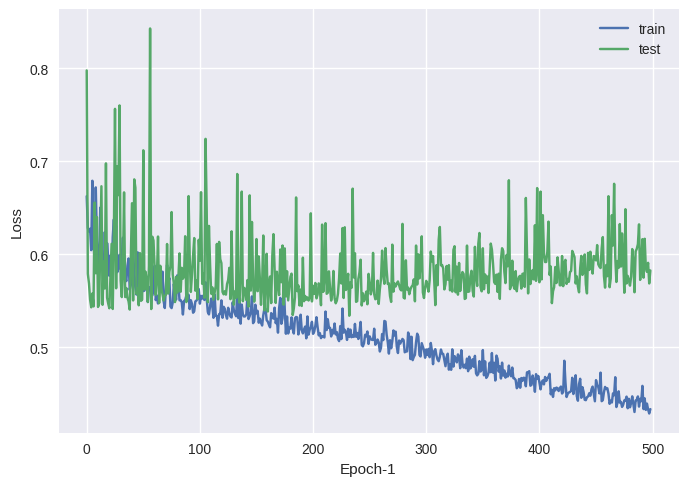

In [12]:
# Prepare and plot loss over time
plt.plot(train_loss,label="train")
plt.plot(test_loss,label="test")
plt.legend()
plt.xlabel("Epoch-1")
plt.ylabel("Loss")
plt.show()

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Correlation coefficient: 0.5262399365782402


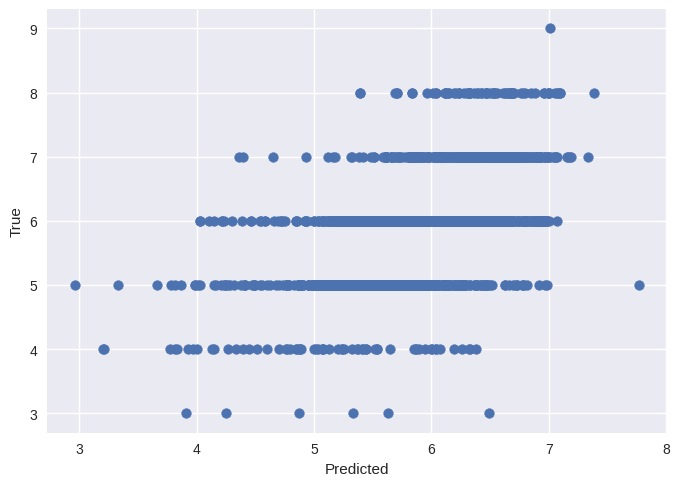

In [13]:
# After the training:

# Prepare scatter plot
y_pred = model.predict(X_test)[:,0]

print("Correlation coefficient:", np.corrcoef(y_pred,y_test)[0,1])
plt.scatter(y_pred,y_test)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [14]:
np.corrcoef(y_pred,y_test)

array([[1.        , 0.52623994],
       [0.52623994, 1.        ]])


# Problems

* Use the notebook as starting point. It already contains the simple network from Exercise 4.1 implemented in Keras.

* Currently, SGD is used without momentum. Try training with a momentum term. Replace SGD with the Adam optimizer and train using that. (See: https://keras.io/api/optimizers/)
* Add two more hidden layers to the network (you can choose the number of nodes but make sure to apply the ReLu activation function after each) and train again.
* Test differet numbers of examples (i.e. change the batch batch size) to be simulataneously used by the network.
* (bonus) optimize the network architecture to get the best correlation coefficient. (Let's see who gets the most out of the data).